In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("car_dataset_12000_ml.csv")
df.head()

,car_brand,purchase_date,purchase_value,engine_condition,no_of_buyers,fuel_type,kilometer_running,reparation_work,today_value
0,Audi,2017-09-21,1355510,Average,5,Hybrid,16298,Yes,110137
1,Ford,2021-12-03,2570355,Average,1,Electric,32490,Yes,517815
2,Mahindra,2016-02-13,2380731,Excellent,5,Petrol,90283,No,160639
3,Mahindra,2024-08-12,948740,Good,1,Petrol,108891,No,241937
4,Honda,2019-08-05,2019877,Average,5,Diesel,68114,Yes,170456


In [5]:
df.shape
df.car_brand

0            Audi
1            Ford
2        Mahindra
3        Mahindra
4           Honda
           ...   
11995      Toyota
11996     Hyundai
11997         BMW
11998     Hyundai
11999         BMW
Name: car_brand, Length: 12000, dtype: str

In [6]:
df.info()
df['car_brand'].value_counts()
df['engine_condition'].value_counts()
df['fuel_type'].value_counts()
df['reparation_work'].value_counts()




<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   car_brand          12000 non-null  str  
 1   purchase_date      12000 non-null  str  
 2   purchase_value     12000 non-null  int64
 3   engine_condition   12000 non-null  str  
 4   no_of_buyers       12000 non-null  int64
 5   fuel_type          12000 non-null  str  
 6   kilometer_running  12000 non-null  int64
 7   reparation_work    12000 non-null  str  
 8   today_value        12000 non-null  int64
dtypes: int64(4), str(5)
memory usage: 1.2 MB


reparation_work
No     6533
Yes    5467
Name: count, dtype: int64

In [7]:
import pandas as pd

# convert to datetime
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

# create car age column
df['car_age'] = (pd.Timestamp.now() - df['purchase_date']).dt.days // 365

# optional: drop purchase_date (not needed anymore)
df = df.drop('purchase_date', axis=1)

In [8]:
df.head()

,car_brand,purchase_value,engine_condition,no_of_buyers,fuel_type,kilometer_running,reparation_work,today_value,car_age
0,Audi,1355510,Average,5,Hybrid,16298,Yes,110137,8
1,Ford,2570355,Average,1,Electric,32490,Yes,517815,4
2,Mahindra,2380731,Excellent,5,Petrol,90283,No,160639,10
3,Mahindra,948740,Good,1,Petrol,108891,No,241937,1
4,Honda,2019877,Average,5,Diesel,68114,Yes,170456,6


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [10]:
categorical_cols = ['car_brand', 'engine_condition', 'fuel_type', 'reparation_work']
numerical_cols = ['purchase_value', 'no_of_buyers', 'kilometer_running', 'car_age']

In [11]:
X = df.drop('today_value', axis=1)
y = df['today_value']

In [12]:
df.head()

,car_brand,purchase_value,engine_condition,no_of_buyers,fuel_type,kilometer_running,reparation_work,today_value,car_age
0,Audi,1355510,Average,5,Hybrid,16298,Yes,110137,8
1,Ford,2570355,Average,1,Electric,32490,Yes,517815,4
2,Mahindra,2380731,Excellent,5,Petrol,90283,No,160639,10
3,Mahindra,948740,Good,1,Petrol,108891,No,241937,1
4,Honda,2019877,Average,5,Diesel,68114,Yes,170456,6


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

In [15]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [16]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', model)
])

In [17]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [18]:
y_pred = pipeline.predict(X_test)

In [19]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 18346.678633333333
R2 Score: 0.9689728590661328


In [20]:
print("Train Score:", pipeline.score(X_train, y_train))
print("Test Score:", pipeline.score(X_test, y_test))

Train Score: 0.9958190187637912
Test Score: 0.9689728590661328


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


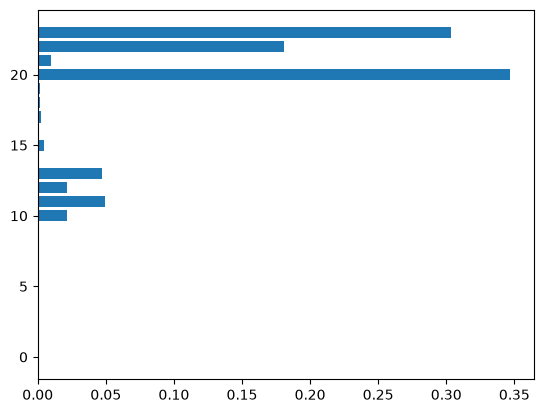

In [24]:
%pip install matplotlib

import matplotlib.pyplot as plt

importances = pipeline.named_steps['model'].feature_importances_
plt.barh(range(len(importances)), importances)
plt.show()

In [25]:
import joblib

joblib.dump(pipeline, "car_price_model_100k.pkl")

['car_price_model_100k.pkl']

In [26]:
new_data = pd.DataFrame({
    'car_brand': ['Toyota'],
    'engine_condition': ['Good'],
    'fuel_type': ['Petrol'],
    'reparation_work': ['No'],
    'purchase_value': [800000],
    'no_of_buyers': [1],
    'kilometer_running': [40000],
    'car_age': [3]
})

prediction = pipeline.predict(new_data)
print("Predicted Price:", prediction)

Predicted Price: [223829.69]
